# Jigsaw reconstruction — end-to-end demonstration

CSE480 Machine Vision · Milestone 1

This notebook runs the whole project on the real photographs, in the order the
brief lays out: enhancement, thresholding, edge detection, segmentation and
contour extraction, piece-edge description, piece-edge matching, and assembly.
Every figure it shows is computed here, not loaded from a previous run, and each
section writes its outputs into the matching `results/` folder.

It ends with the honest result: the blind reconstruction places **24 of 35**
pieces correctly. It is **not** a complete reconstruction, and §8 explains what
measurement says is responsible.

Run time: about two minutes, most of it in the final assembly search.

In [1]:
import os
import sys
from pathlib import Path

# Work from the repository root whether the notebook is opened from there or
# from notebooks/.
ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

RESULTS = ROOT / 'results'
for folder in ('enhanced_images', 'masks', 'contours', 'edge_visualisations',
               'reconstructed_images', 'evaluation_results'):
    (RESULTS / folder).mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['image.cmap'] = 'gray'


def show(panels, title=None, save=None, cmaps=None):
    """Show named panels side by side and optionally save each one."""
    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
    axes = np.atleast_1d(axes)
    for axis, (name, image) in zip(axes, panels.items()):
        array = np.asarray(image)
        if array.ndim == 3:
            axis.imshow(cv2.cvtColor(array.astype(np.uint8), cv2.COLOR_BGR2RGB))
        else:
            axis.imshow(array, cmap=(cmaps or {}).get(name, 'gray'))
        axis.set_title(name)
        axis.axis('off')
        if save is not None:
            slug = name.lower().replace(' ', '_').replace('/', '_')
            cv2.imwrite(str(save / ('%s.png' % slug)),
                        np.clip(array, 0, 255).astype(np.uint8))
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()


print('working directory:', ROOT)

working directory: /media/mohamed/Robotics3/jigsaw_project_submission_v2/jigsaw_project_submission


/home/mohamed/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. The input

One of the fifty photographs of the assembled puzzle, kept in `data/input/`.
Everything in sections 1 to 4 is computed from this single frame; the piece
images used from section 5 onwards were built from all fifty by
`python3 -m scripts.build_ground_truth`.

frame (1080, 1920, 3) -> working copy (360, 640, 3)


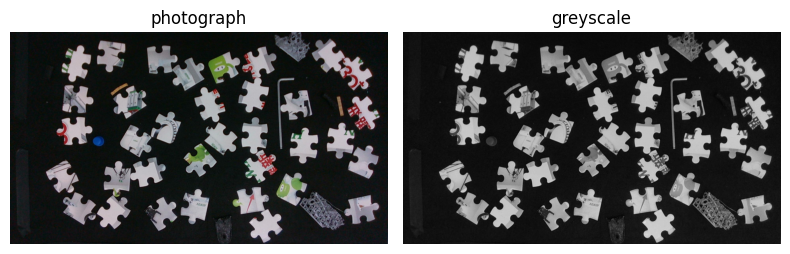

In [2]:
frame = cv2.imread(str(ROOT / 'data/input/demo_frame.jpg'))
assert frame is not None, 'data/input/demo_frame.jpg is missing'
grey = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# A half-width copy keeps the from-scratch filters -- especially Canny's
# per-pixel non-maximum suppression -- to a few seconds each.
scale = 640 / frame.shape[1]
small = cv2.resize(frame, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
small_grey = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

print('frame', frame.shape, '-> working copy', small.shape)
show({'photograph': frame, 'greyscale': grey})

## 2. Milestone 1 §1 — Image enhancement

`src/enhancement.py`, all from scratch on NumPy arrays. Every filter is built on
one `convolution` routine, so the whole library shares a single padding and
accumulation convention. The median filter is the exception the brief asks about:
a median is a rank statistic, not a weighted sum, so some neighbourhood
enumeration is unavoidable.

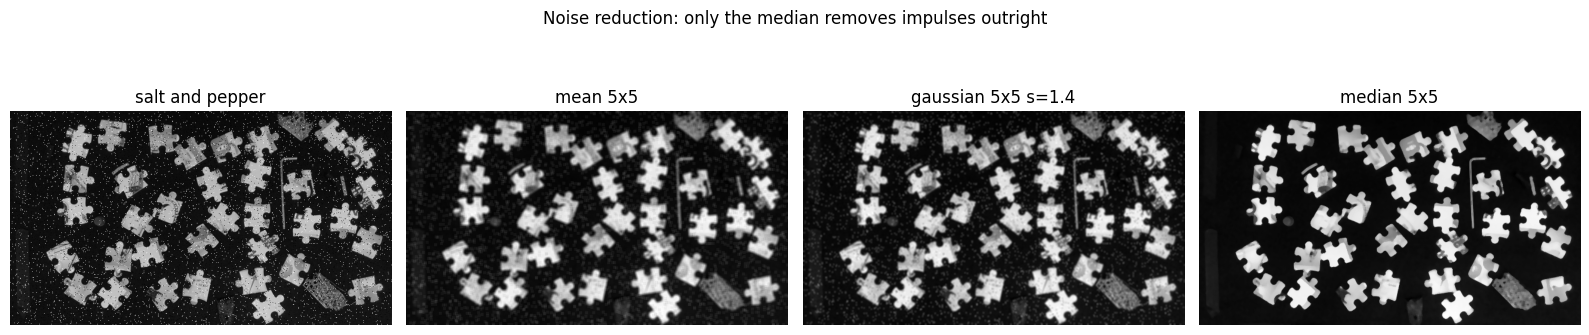

In [3]:
from src.enhancement import (contrast_stretch, gaussian_filter, gaussian_kernel,
                             histogram, histogram_equalization, laplacian_sharpen,
                             mean_filter, median_filter, unsharp_mask)

noisy = small_grey.astype(float).copy()
rng = np.random.default_rng(480)
salt = rng.random(noisy.shape)
noisy[salt < 0.02] = 0
noisy[salt > 0.98] = 255

show({'salt and pepper': noisy,
      'mean 5x5': mean_filter(noisy, 5),
      'gaussian 5x5 s=1.4': gaussian_filter(noisy, 5, 1.4),
      'median 5x5': median_filter(noisy.astype(np.uint8), 5)},
     title='Noise reduction: only the median removes impulses outright',
     save=RESULTS / 'enhanced_images')

In [4]:
kernel = gaussian_kernel(5, 1.4)
print('Gaussian kernel, derived from size=5 and sigma=1.4 (sums to %.6f):' % kernel.sum())
print(np.round(kernel, 4))

Gaussian kernel, derived from size=5 and sigma=1.4 (sums to 1.000000):
[[0.0121 0.0261 0.0337 0.0261 0.0121]
 [0.0261 0.0561 0.0724 0.0561 0.0261]
 [0.0337 0.0724 0.0935 0.0724 0.0337]
 [0.0261 0.0561 0.0724 0.0561 0.0261]
 [0.0121 0.0261 0.0337 0.0261 0.0121]]


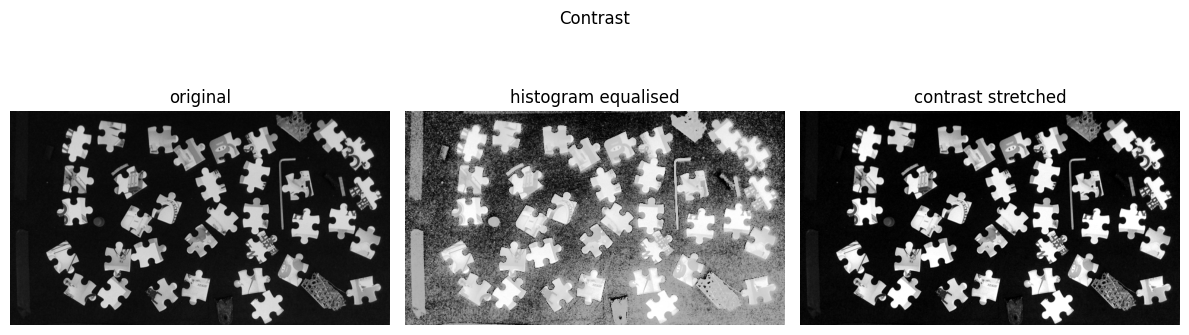

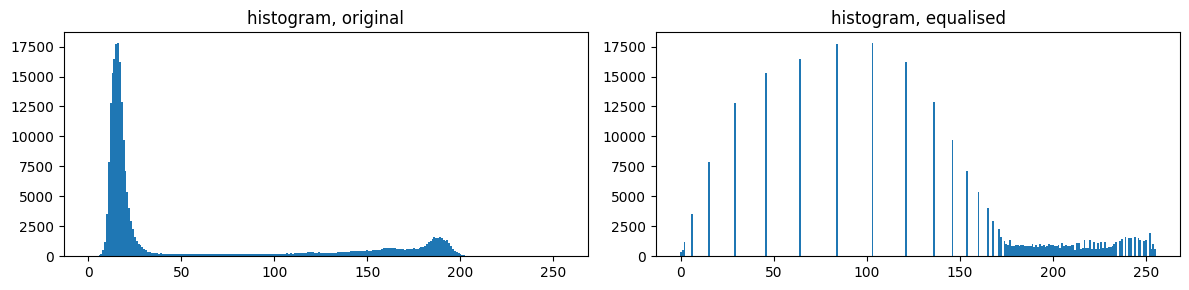

In [5]:
show({'original': small_grey,
      'histogram equalised': histogram_equalization(small_grey),
      'contrast stretched': contrast_stretch(small_grey)},
     title='Contrast', save=RESULTS / 'enhanced_images')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for axis, (name, image) in zip(axes, {'original': small_grey,
                                      'equalised': histogram_equalization(small_grey)}.items()):
    axis.bar(np.arange(256), histogram(image), width=1.0)
    axis.set_title('histogram, ' + name)
fig.tight_layout()
plt.show()

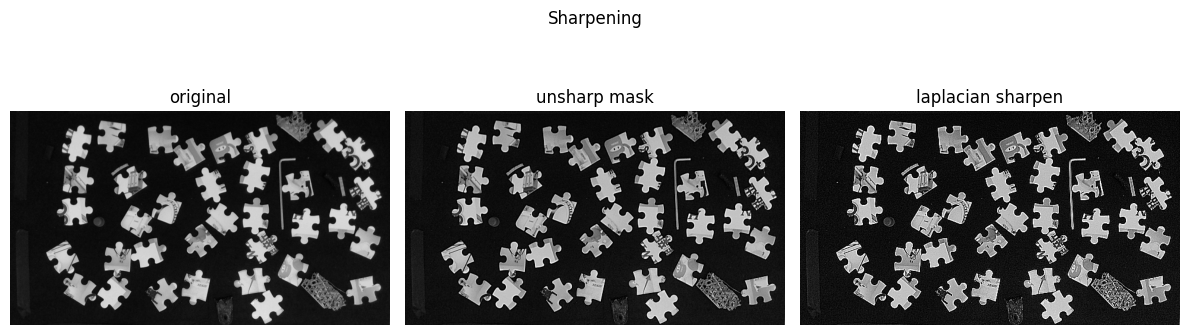

In [6]:
show({'original': small_grey,
      'unsharp mask': unsharp_mask(small_grey, 5, 1.4, 1.2),
      'laplacian sharpen': laplacian_sharpen(small_grey, 0.6)},
     title='Sharpening', save=RESULTS / 'enhanced_images')

## 3. Milestone 1 §1 — Thresholding

Global, Otsu and adaptive, all in `src/thresholding.py`. Otsu picks its own
threshold by maximising between-class variance over the library's own histogram.

Otsu chose t = 90


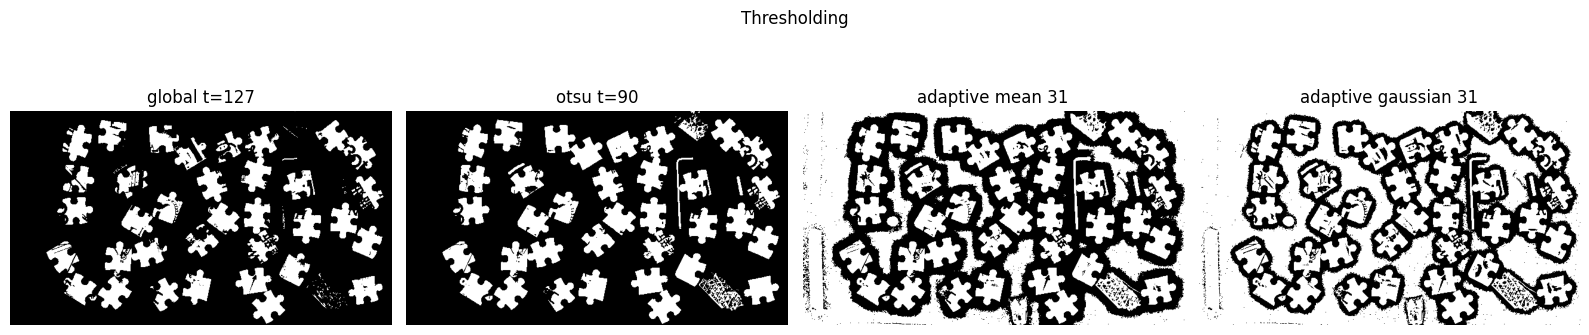

In [7]:
from src.thresholding import adaptive_threshold, global_threshold, otsu_threshold

otsu_mask, otsu_t = otsu_threshold(small_grey)
print('Otsu chose t = %d' % otsu_t)

show({'global t=127': global_threshold(small_grey, 127),
      'otsu t=%d' % otsu_t: otsu_mask,
      'adaptive mean 31': adaptive_threshold(small_grey, 31, 5),
      'adaptive gaussian 31': adaptive_threshold(small_grey, 31, 5, method='gaussian')},
     title='Thresholding', save=RESULTS / 'masks')

## 4. Milestone 1 §2 — Edge detection

Sobel and Prewitt each return **magnitude and orientation**, and Canny is
implemented stage by stage so every intermediate can be inspected: smoothing,
gradient, non-maximum suppression, double thresholding, hysteresis.

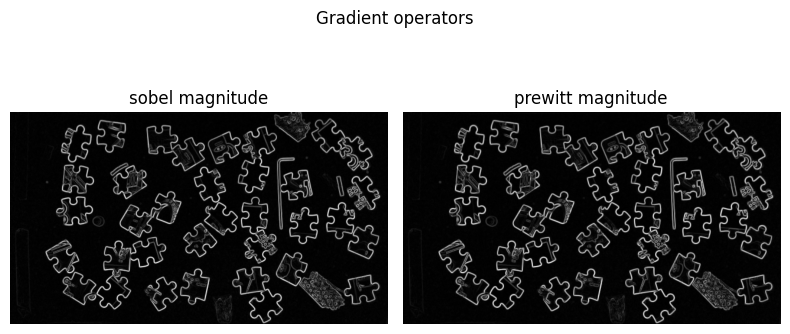

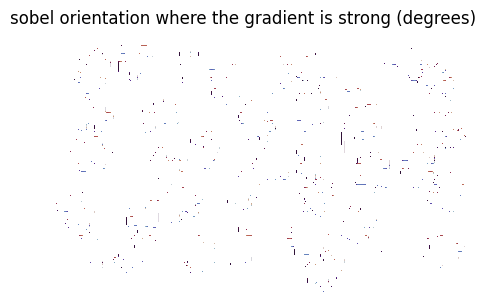

In [8]:
from src.edge_detection import canny, prewitt, sobel

sobel_magnitude, sobel_orientation = sobel(small_grey.astype(float))
prewitt_magnitude, _ = prewitt(small_grey.astype(float))

show({'sobel magnitude': sobel_magnitude,
      'prewitt magnitude': prewitt_magnitude},
     title='Gradient operators', save=RESULTS / 'edge_visualisations')

fig, axis = plt.subplots(figsize=(6, 4))
strong = sobel_magnitude > 0.3 * sobel_magnitude.max()
axis.imshow(np.where(strong, np.degrees(sobel_orientation), np.nan), cmap='twilight')
axis.set_title('sobel orientation where the gradient is strong (degrees)')
axis.axis('off')
plt.show()

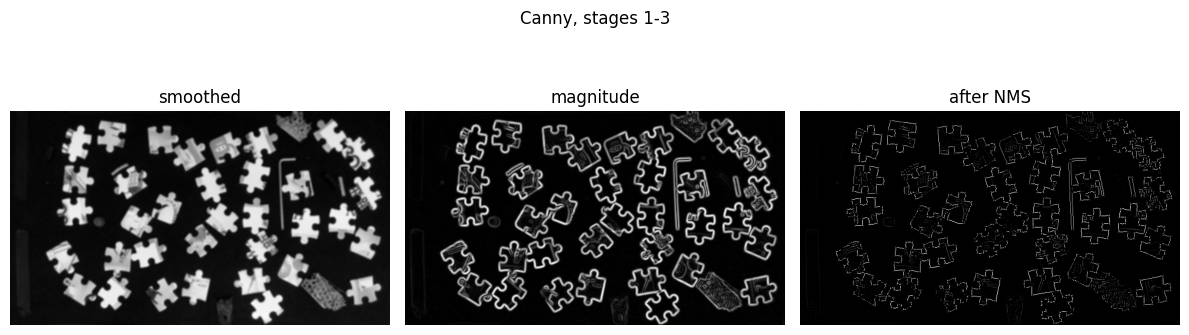

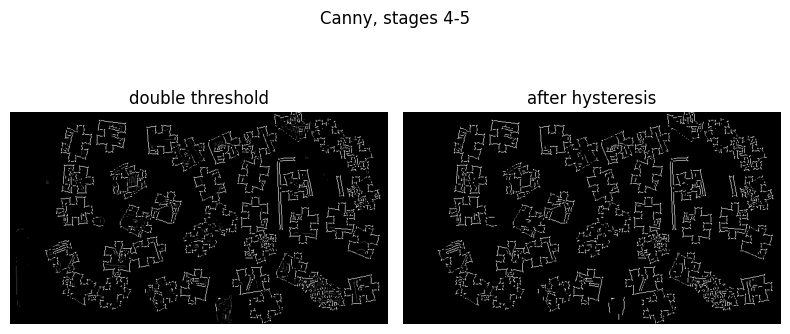

magnitude above zero: 230396 px
surviving NMS:        41888 px
final edge map:       11030 px


In [9]:
edges, stages = canny(small_grey.astype(float), sigma=1.4, low=30, high=70)

show({'smoothed': stages['smoothed'],
      'magnitude': stages['magnitude'],
      'after NMS': stages['nms']},
     title='Canny, stages 1-3', save=RESULTS / 'edge_visualisations')
show({'double threshold': stages['double_threshold'],
      'after hysteresis': edges},
     title='Canny, stages 4-5', save=RESULTS / 'edge_visualisations')

print('magnitude above zero: %d px' % np.count_nonzero(stages['magnitude'] > 1e-9))
print('surviving NMS:        %d px' % np.count_nonzero(stages['nms'] > 1e-9))
print('final edge map:       %d px' % np.count_nonzero(edges))

## 5. Milestone 1 §3 — Segmentation and contour extraction

Connected components and Moore boundary tracing are both written from scratch in
`src/segmentation.py` and `src/contour_extraction.py`. The tracer is checked
point-for-point against `cv2.findContours` in the test suite; OpenCV is used here
only as that reference, never in the pipeline.

foreground 26.7% of the frame at Otsu t=93
47 connected components; the ten largest have areas [45914, 31792, 31283, 30677, 30038, 29965, 28157, 16942, 15776, 15711]


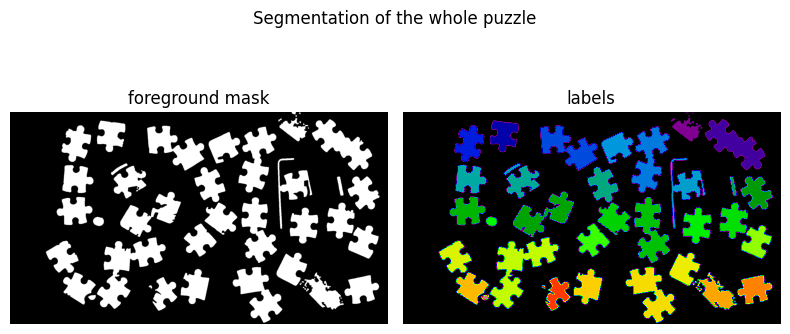

In [10]:
from src.contour_extraction import extract_contour_cv2, polygon_area, trace_boundary
from src.frame_extraction import frame_mask
from src.segmentation import connected_components

mask, threshold = frame_mask(frame)
labels, components = connected_components(mask)
components = sorted(components, key=lambda c: c.area, reverse=True)

print('foreground %.1f%% of the frame at Otsu t=%d' % (100 * (mask > 0).mean(), threshold))
print('%d connected components; the ten largest have areas %s'
      % (len(components), [c.area for c in components[:10]]))

show({'foreground mask': mask,
      'labels': labels},
     title='Segmentation of the whole puzzle', save=RESULTS / 'masks',
     cmaps={'labels': 'nipy_spectral'})

traced 1891 boundary points; identical to cv2.findContours: True
enclosed area 44968 px (mask area 45914 px)


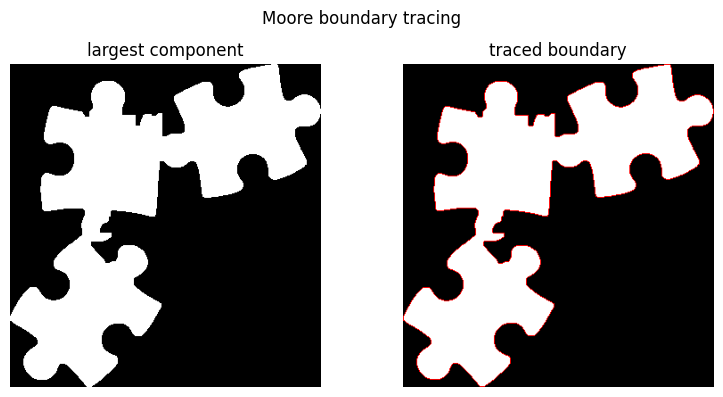

In [11]:
# The largest component is the assembled puzzle body; trace its outline.
largest = components[0]
component_mask = (np.asarray(largest.mask) > 0).astype(np.uint8) * 255

traced = trace_boundary(component_mask)
reference = extract_contour_cv2(component_mask)
print('traced %d boundary points; identical to cv2.findContours: %s'
      % (len(traced), set(map(tuple, traced.tolist())) == set(map(tuple, reference.tolist()))))
print('enclosed area %.0f px (mask area %d px)'
      % (abs(polygon_area(traced)), largest.area))

canvas = cv2.cvtColor(component_mask, cv2.COLOR_GRAY2BGR)
canvas[traced[:, 1], traced[:, 0]] = (0, 0, 255)
show({'largest component': component_mask, 'traced boundary': canvas},
     title='Moore boundary tracing', save=RESULTS / 'contours')

## 6. Milestone 1 §4 — Piece-edge description

Each piece is warped onto a canonical canvas, its four corners located, and each
side described by a signed silhouette profile, a TAB/BLANK/FLAT label and an
interior colour strip sampled at three depths. Samples from `data/sample_pieces/`.

piece  1: top=FLAT, right=FLAT, bottom=TAB, left=BLANK
piece  2: top=BLANK, right=FLAT, bottom=BLANK, left=FLAT
piece  8: top=TAB, right=FLAT, bottom=TAB, left=BLANK
piece 15: top=BLANK, right=FLAT, bottom=BLANK, left=TAB
piece 22: top=TAB, right=FLAT, bottom=TAB, left=BLANK
piece 35: top=TAB, right=BLANK, bottom=FLAT, left=FLAT


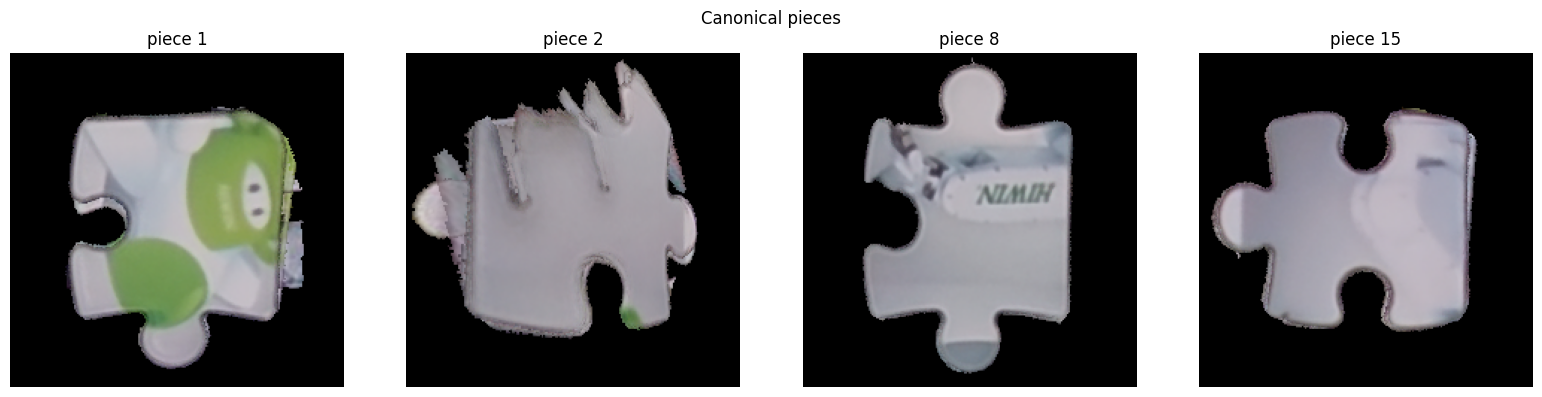

In [12]:
from src.piece_geometry import describe_piece

sample_paths = sorted((ROOT / 'data/sample_pieces').glob('piece_*.png'))
samples = []
for path in sample_paths:
    rgba = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    samples.append(describe_piece(int(path.stem.split('_')[1]), rgba[:, :, :3], rgba[:, :, 3]))

for piece in samples:
    print('piece %2d: %s' % (piece.id, ', '.join('%s=%s' % (s.name, s.kind.value)
                                                 for s in piece.sides)))

show({('piece %d' % p.id): p.image for p in samples[:4]}, title='Canonical pieces')

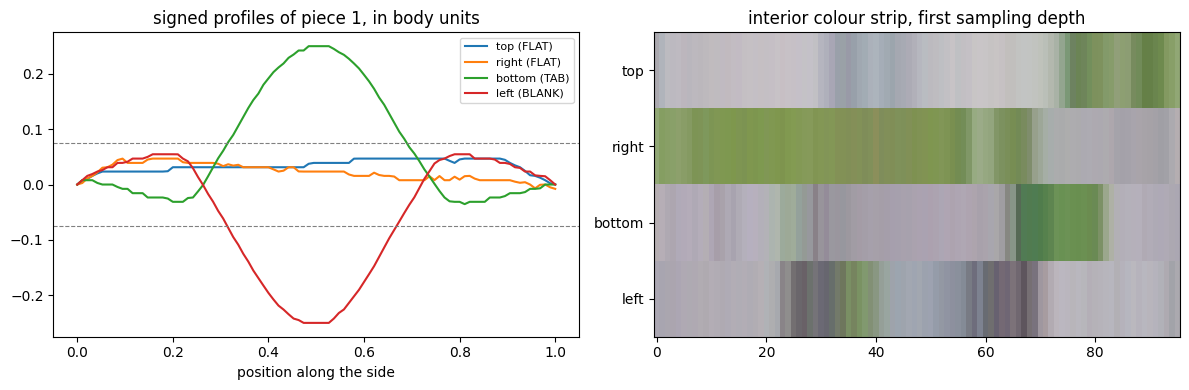

In [13]:
piece = samples[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for side in piece.sides:
    axes[0].plot(np.linspace(0, 1, len(side.profile)), side.profile,
                 label='%s (%s)' % (side.name, side.kind.value))
axes[0].axhline(0.075, color='grey', lw=0.8, ls='--')
axes[0].axhline(-0.075, color='grey', lw=0.8, ls='--')
axes[0].set_title('signed profiles of piece %d, in body units' % piece.id)
axes[0].set_xlabel('position along the side')
axes[0].legend(fontsize=8)

strip = np.stack([side.colors[:, :3] for side in piece.sides])
axes[1].imshow(strip[:, :, ::-1], aspect='auto')
axes[1].set_yticks(range(4), [s.name for s in piece.sides])
axes[1].set_title('interior colour strip, first sampling depth')
fig.tight_layout()
plt.show()

## 7. Milestone 1 §5 — Piece-edge matching

The compatibility of two sides is a single number: Mahalanobis gradient
compatibility on the colour strips. Shape is a **gate only** — a tab may meet a
blank and nothing else — because every weighted shape term tested made matching
monotonically worse on this die-cut puzzle, where all tabs are the same shape.

In [14]:
from src.edge_compatibility import compatibility, mgc_dissimilarity
from src.piece_geometry import SideType
from src.synthetic import cut_image

# A known 2x2 cut from a smooth image: every true partner is known exactly.
ys, xs = np.mgrid[0:256, 0:256].astype(float)
image = np.clip(np.dstack([128 + 110 * np.sin(xs / 29.0),
                           128 + 110 * np.cos(ys / 33.0),
                           128 + 110 * np.sin((xs + ys) / 41.0)]), 0, 255).astype(np.uint8)
cut, _ = cut_image(image, 2, 2, margin=48, seed=3)
quartet = [describe_piece(i, patch, patch_mask) for i, (patch, patch_mask) in enumerate(cut)]

top_left, top_right, bottom_left, bottom_right = quartet
source = top_left.sides[1]                       # right side of the top-left piece
print('true partner      : %.3f' % mgc_dissimilarity(source, top_right.sides[3]))
print('a side from elsewhere: %.3f' % mgc_dissimilarity(source, bottom_right.sides[3]))
print('tab against tab   : %s' % compatibility(source, source))

true partner      : 45.879
a side from elsewhere: 594.902
tab against tab   : inf


In [15]:
# On the real pieces: where does the true partner rank among all candidates?
# This is the protocol of scripts/evaluate_matcher.py -- every internal seam
# scored in both directions, against every side of every other piece that the
# tab/blank gate admits.
from src.piece_geometry import rotate_piece
from src.solver import build_variants

layout = json.loads((ROOT / 'data/ground_truth/layout.json').read_text())
rows, cols = layout['grid']
order = layout['positions_piece_id']
solved = layout['solved_rotations_ccw']

solved_pieces = []
for pid in order:                       # in cell order, turned as they sit in the puzzle
    rgba = cv2.imread(str(ROOT / 'data/pieces' / ('piece_%02d.png' % pid)),
                      cv2.IMREAD_UNCHANGED)
    base = describe_piece(pid, rgba[:, :, :3], rgba[:, :, 3])
    solved_pieces.append(rotate_piece(base, int(solved[str(pid)])))

seams = []
for cell in range(rows * cols):
    row, col = divmod(cell, cols)
    if col < cols - 1:
        seams.append((cell, 1, cell + 1, 3))     # right side meets the next left side
    if row < rows - 1:
        seams.append((cell, 2, cell + cols, 0))  # bottom side meets the next top side

candidates = [(index, j, piece.sides[j])
              for index, piece in enumerate(solved_pieces) for j in range(4)]

ranks = []
for a, a_side, b, b_side in seams:
    for (src, src_side), (dst, dst_side) in (((a, a_side), (b, b_side)),
                                             ((b, b_side), (a, a_side))):
        source = solved_pieces[src].sides[src_side]
        scored = []
        for index, j, side in candidates:
            if index == src:
                continue
            value = compatibility(source, side)
            if np.isfinite(value):               # the gate rejects the rest outright
                scored.append((value, index, j))
        scored.sort()
        ranks.append(next((k + 1 for k, (_, i, j) in enumerate(scored)
                           if i == dst and j == dst_side), len(scored) + 1))

ranks = np.array(ranks)
print('%d internal seams, scored in both directions' % len(seams))
print('true partner ranked first : %3d / %d  (%.1f%%)'
      % ((ranks == 1).sum(), len(ranks), 100 * (ranks == 1).mean()))
print('true partner in the top 3 : %.1f%%' % (100 * (ranks <= 3).mean()))
print('median rank               : %d' % np.median(ranks))

58 internal seams, scored in both directions
true partner ranked first :  54 / 116  (46.6%)
true partner in the top 3 : 58.6%
median rank               : 2


46.6% rank-1 is what the assembly search has to work with. For comparison, plain
colour SSD reaches 22.4% and the project's earlier 0.6-shape/0.4-colour blend
reached 7.8% — reproduce both with `python3 -m scripts.evaluate_matcher`.

## 8. Milestone 1 §6 — Assembly

The solver is handed an unordered bag of pieces with no identity, position or
orientation. It infers the grid shape, then searches over both position and
rotation with a beam search.

First a synthetic puzzle cut from a known image, where the correct answer is
recoverable exactly — this is the check that the search itself works.

grid inferred: (2, 3)
piece order  : [5, 4, 3, 2, 1, 0] (truth is 0..5 in either reading)


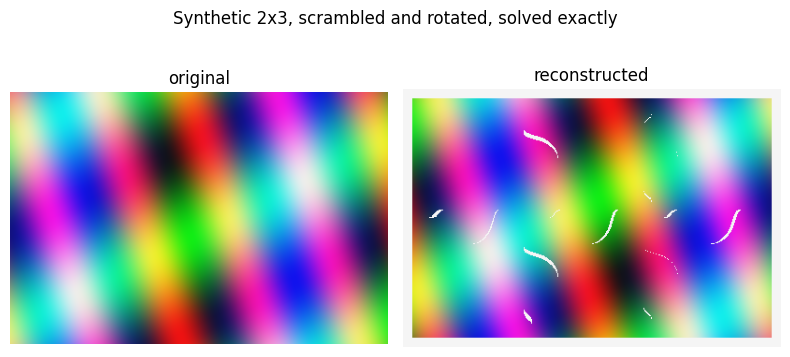

In [16]:
from src.solver import render_grid, solve

ys, xs = np.mgrid[0:2 * 128, 0:3 * 128].astype(float)
known = np.clip(np.dstack([128 + 110 * np.sin(xs / 37.0),
                           128 + 110 * np.sin((xs + 2 * ys) / 61.0),
                           128 + 110 * np.cos((3 * xs - ys) / 43.0)]), 0, 255).astype(np.uint8)
cut, _ = cut_image(known, 2, 3, margin=48, seed=7)
pieces = [describe_piece(i, patch, patch_mask) for i, (patch, patch_mask) in enumerate(cut)]

rng = np.random.default_rng(7)
turned = [rotate_piece(p, int(rng.integers(0, 4))) for p in pieces]
scrambled = [turned[i] for i in rng.permutation(len(turned))]

variants = build_variants(scrambled)
result = solve(scrambled, beam_width=64, per_state=4, variants=variants)
print('grid inferred: %s' % (result.grid,))
print('piece order  : %s (truth is 0..5 in either reading)' % result.piece_ids())
show({'original': known, 'reconstructed': render_grid(variants, result, margin=10)},
     title='Synthetic 2x3, scrambled and rotated, solved exactly')

Now the real puzzle. The 35 photographed pieces are shuffled and each is given a
random rotation, so the solver receives nothing it could exploit. Ground truth is
read only afterwards, to score the answer. This search takes about 40 seconds.

In [17]:
import time
from src.evaluation import blind_accuracy

seed_rng = np.random.default_rng(480)
bag, applied = [], {}
for path in sorted((ROOT / 'data/pieces').glob('piece_*.png')):
    rgba = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    pid = int(path.stem.split('_')[1])
    turn = int(seed_rng.integers(0, 4))
    applied[pid] = turn
    bag.append(rotate_piece(describe_piece(pid, rgba[:, :, :3], rgba[:, :, 3]), turn))
bag = [bag[i] for i in seed_rng.permutation(len(bag))]

started = time.perf_counter()
variants = build_variants(bag)
reconstruction = solve(bag, beam_width=10000, per_state=16, variants=variants,
                       progress=lambda message: print('  ' + message, flush=True))
elapsed = time.perf_counter() - started
print('grid inferred %s, every cell filled: %s, in %.0f s'
      % (reconstruction.grid, reconstruction.complete, elapsed))

  filling 35 cells


grid inferred (5, 7), every cell filled: True, in 52 s


reported in the rotated 180 degrees reading
position    24 / 35  (68.6%)
orientation 23 / 35  (65.7%)
neighbours  34 / 58  (58.6%)
complete reconstruction: False


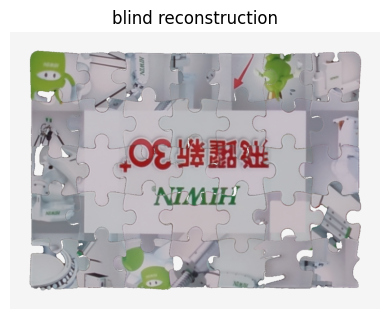

In [18]:
rendered = render_grid(variants, reconstruction)
cv2.imwrite(str(RESULTS / 'reconstructed_images/notebook_reconstruction.png'), rendered)

accuracy = blind_accuracy(reconstruction, applied, layout)
reported = accuracy['reported']
print('reported in the %s reading' % accuracy['reported_orientation'])
print('position    %2d / %d  (%.1f%%)' % (reported['position_hits'], 35,
                                          100 * reported['position_accuracy']))
print('orientation %2d / %d  (%.1f%%)' % (reported['orientation_hits'], 35,
                                          100 * reported['orientation_accuracy']))
print('neighbours  %2d / %d  (%.1f%%)' % (reported['neighbour_hits'],
                                          reported['neighbour_total'],
                                          100 * reported['neighbour_accuracy']))
print('complete reconstruction: %s' % bool(reported['complete_reconstruction']))

(RESULTS / 'evaluation_results/notebook_reconstruction.json').write_text(
    json.dumps({'grid': list(reconstruction.grid), 'runtime_seconds': elapsed,
                'quality': reconstruction.quality, 'accuracy': accuracy}, indent=2))

show({'blind reconstruction': rendered})

## 9. What this result means

The search fills every cell of a correctly inferred 5×7 grid, and about two
thirds of the pieces land where they belong. It is **not** a complete
reconstruction.

`python3 -m scripts.evaluate_solver` scores the *true* arrangement under the
solver's own objective and finds that from beam width 3 000 upwards the search
returns arrangements scoring **better** than the truth (1735 against 1943).
Widening the beam lowers the objective monotonically while accuracy wanders
between 54% and 69%. So the limit is the compatibility measure, not the search:
minimising this objective harder cannot make the answer more correct. A learned
pairwise measure — Milestone 2 — is what attacks that bottleneck.

Three properties of this particular puzzle are what make it hard, and all three
are measured rather than assumed:

1. It is **die-cut**: every tab has the same profile, so shape carries almost no
   identifying information and can only be used as a gate.
2. **Flat sides cannot be classified reliably per piece** — three of the 35 come
   out with the wrong flat count under every profile statistic swept — so the
   solver charges a cost for silhouette disagreement instead of trusting a label.
3. One true seam **breaks the tab/blank gate**, because a clamp damages piece 2's
   silhouette in all fifty photographs, so the gate has to be a penalty rather
   than a hard rule or the correct answer becomes unreachable.

`report/milestone_1_report.md` states each of these with the measurement behind it.